<a href="https://colab.research.google.com/github/ChinthakindhiNishitha/DeepLearining/blob/main/week7%2C8(LeNet%2CAlexNet_).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import h5py
from keras.models import Sequential
from keras.layers import Conv2D, AveragePooling2D, Flatten, Dense, Dropout, Input
from keras.utils import to_categorical
from sklearn.model_selection import train_test_split

# ================================
# LOAD DATASET (CORRECT KEYS)
# ================================
train_path = "/content/drive/MyDrive/Signs_Data_Training.h5"
test_path = "/content/drive/MyDrive/Signs_Data_Testing.h5"

# Load training data
with h5py.File(train_path, "r") as f:
    print("Train keys:", list(f.keys()))
    x_train = np.array(f["train_set_x"])
    y_train = np.array(f["train_set_y"])

# Load testing data
with h5py.File(test_path, "r") as f:
    print("Test keys:", list(f.keys()))
    x_test = np.array(f["test_set_x"])
    y_test = np.array(f["test_set_y"])

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

# ================================
# PREPROCESSING
# ================================

# Normalize
x_train = x_train / 255.0
x_test = x_test / 255.0

# Train-validation split
x_train_main, x_val, y_train_main, y_val = train_test_split(
    x_train, y_train, test_size=0.2, random_state=42
)

# One-hot encoding
num_classes = len(np.unique(y_train))

y_train_main = to_categorical(y_train_main, num_classes)
y_val = to_categorical(y_val, num_classes)
y_test = to_categorical(y_test, num_classes)

# ================================
# BUILD LeNet-5 MODEL
# ================================
input_shape = x_train.shape[1:]  # e.g., (64, 64, 3)

model = Sequential()

# Keras recommends using Input(shape) as the first layer in Sequential models
model.add(Input(shape=input_shape))
model.add(Conv2D(6, (5, 5), activation='tanh'))
model.add(AveragePooling2D((2, 2)))

model.add(Conv2D(16, (5, 5), activation='tanh'))
model.add(AveragePooling2D((2, 2)))

model.add(Flatten())

model.add(Dense(120, activation='tanh'))
model.add(Dropout(0.2)) # Added Dropout layer
model.add(Dense(84, activation='tanh'))
model.add(Dense(num_classes, activation='softmax'))

# ================================
# COMPILE & TRAIN
# ================================
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()

model.fit(
    x_train_main, y_train_main,
    epochs=20,
    batch_size=128,
    validation_data=(x_val, y_val)
)

# ================================
# EVALUATE
# ================================
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)

Train keys: ['list_classes', 'train_set_x', 'train_set_y']
Test keys: ['list_classes', 'test_set_x', 'test_set_y']
Train shape: (1080, 64, 64, 3)
Test shape: (120, 64, 64, 3)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 6)      │           456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_2             │ (None, 30, 30, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 26, 26, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_3             │ (None, 13, 13, 16)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2704)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 120)            │       324,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │           510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 338,146 (1.29 MB)

 Trainable params: 338,146 (1.29 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 611ms/step - accuracy: 0.1771 - loss: 2.0246 - val_accuracy: 0.1620 - val_loss: 1.8082
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.2512 - loss: 1.7350 - val_accuracy: 0.3056 - val_loss: 1.6815
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.3981 - loss: 1.5984 - val_accuracy: 0.4815 - val_loss: 1.5547
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.5660 - loss: 1.4420 - val_accuracy: 0.4722 - val_loss: 1.4504
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.5799 - loss: 1.2949 - val_accuracy: 0.5741 - val_loss: 1.3714
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.6296 - loss: 1.1556 - val_accuracy: 0.5694 - val_loss: 1.2100
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.6377 - loss: 1.0248 - val_accuracy: 0.6389 - val_loss: 1.0691
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.7025 - loss: 0.8912 - val_accuracy: 0.6898 - val_loss: 0.9805

In [ ]:
# ================================
# IMPORT LIBRARIES
# ================================
import numpy as np
import h5py
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical

# ================================
# LOAD DATASET
# ================================
def load_dataset():
    with h5py.File("/content/drive/MyDrive/Signs_Data_Training.h5", "r") as f:
        X_train = np.array(f["train_set_x"])
        Y_train = np.array(f["train_set_y"])

    with h5py.File("/content/drive/MyDrive/Signs_Data_Testing.h5", "r") as f:
        X_test = np.array(f["test_set_x"])
        Y_test = np.array(f["test_set_y"])

    # Normalize
    X_train = X_train / 255.0
    X_test = X_test / 255.0

    # One-hot encoding
    Y_train = to_categorical(Y_train, 6)
    Y_test = to_categorical(Y_test, 6)

    return X_train, Y_train, X_test, Y_test


# ================================
# TUNED LeNet-5 MODEL
# ================================
def build_tuned_lenet():

    model = models.Sequential([

        layers.Input(shape=(64,64,3)),

        # 🔥 Conv Block 1
        layers.Conv2D(32, (5,5), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        # 🔥 Conv Block 2
        layers.Conv2D(64, (5,5), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        # 🔥 Conv Block 3 (NEW - added depth)
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        layers.Flatten(),

        # 🔥 Fully Connected Layers
        layers.Dense(120, activation='relu'),


        layers.Dense(84, activation='relu'),


        layers.Dense(6, activation='softmax')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


# ================================
# TRAIN & EVALUATE
# ================================
X_train, Y_train, X_test, Y_test = load_dataset()

model = build_tuned_lenet()

model.summary()

history = model.fit(
    X_train,
    Y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2
)

test_loss, test_acc = model.evaluate(X_test, Y_test)
print("Test Accuracy:", test_acc)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 32)     │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 64)     │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 120)            │       983,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 6)              │           510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,122,282 (4.28 MB)

 Trainable params: 1,121,834 (4.28 MB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 0.4005 - loss: 1.6843 - val_accuracy: 0.1296 - val_loss: 1.7812
Epoch 2/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.7685 - loss: 0.6028 - val_accuracy: 0.2176 - val_loss: 1.7705
Epoch 3/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.9051 - loss: 0.3113 - val_accuracy: 0.1806 - val_loss: 2.0106
Epoch 4/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - accuracy: 0.9699 - loss: 0.1439 - val_accuracy: 0.1806 - val_loss: 2.5449
Epoch 5/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.9838 - loss: 0.0727 - val_accuracy: 0.1806 - val_loss: 3.1347
Epoch 6/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.9931 - loss: 0.0421 - val_accuracy: 0.1806 - val_loss: 3.6213
Epoch 7/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.9988 - loss: 0.0203 - val_accuracy: 0.1806 - val_loss: 4.0088
Epoch 8/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step - accuracy: 1.0000 - loss: 0.0101 - val_accuracy: 0.1806 - val_loss:

Train shape: (1080, 64, 64, 3)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 96)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 26, 26, 96)     │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 12, 12, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 5, 5, 384)      │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 5, 5, 384)      │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 5, 5, 256)      │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │     4,198,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │        24,582 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,752,902 (94.42 MB)

 Trainable params: 24,752,198 (94.42 MB)

 Non-trainable params: 704 (2.75 KB)

Epoch 1/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 104s 683ms/step - accuracy: 0.4287 - loss: 1.4020 - val_accuracy: 0.1667 - val_loss: 1.7371
Epoch 2/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 103s 756ms/step - accuracy: 0.7259 - loss: 0.7056 - val_accuracy: 0.5417 - val_loss: 1.3429
Epoch 3/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 89s 658ms/step - accuracy: 0.8556 - loss: 0.3980 - val_accuracy: 0.8500 - val_loss: 0.6001
Epoch 4/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 88s 654ms/step - accuracy: 0.9241 - loss: 0.2392 - val_accuracy: 0.8250 - val_loss: 0.5455
Epoch 5/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 89s 656ms/step - accuracy: 0.9639 - loss: 0.1309 - val_accuracy: 0.9167 - val_loss: 0.2008
Epoch 6/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 91s 673ms/step - accuracy: 0.9648 - loss: 0.0884 - val_accuracy: 0.7750 - val_loss: 0.5344
Epoch 7/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 90s 669ms/step - accuracy: 0.9657 - loss: 0.1196 - val_accuracy: 0.2833 - val_loss: 4.7764
Epoch 8/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 149s 724ms/step - accuracy: 0.9769 - loss

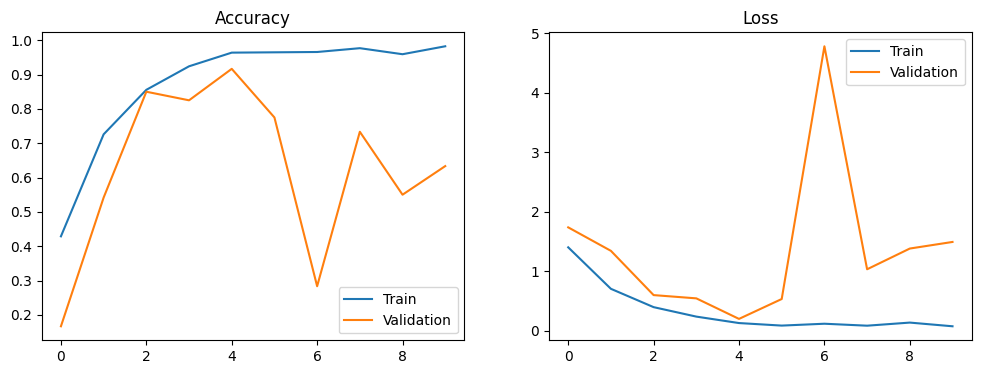

6696

In [ ]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization
import numpy as np
import h5py
import matplotlib.pyplot as plt
import gc

# Clear session
keras.backend.clear_session()

# -------------------------------
# 1. Load Dataset
# -------------------------------
def load_dataset():
    with h5py.File("/content/drive/MyDrive/Signs_Data_Training.h5", "r") as f:
        X_train = np.array(f["train_set_x"])
        Y_train = np.array(f["train_set_y"])

    with h5py.File("/content/drive/MyDrive/Signs_Data_Testing.h5", "r") as f:
        X_test = np.array(f["test_set_x"])
        Y_test = np.array(f["test_set_y"])

    return X_train, Y_train, X_test, Y_test

X_train, Y_train, X_test, Y_test = load_dataset()

print("Train shape:", X_train.shape)

# -------------------------------
# 2. Preprocessing
# -------------------------------

# Normalize
X_train = X_train / 255.0
X_test = X_test / 255.0

# Classes
num_classes = len(np.unique(Y_train))

# One-hot encoding
Y_train = keras.utils.to_categorical(Y_train, num_classes)
Y_test = keras.utils.to_categorical(Y_test, num_classes)

# Resize to AlexNet size (227x227 is original, using 224 or 112 is ok)
IMG_SIZE = 112
X_train = tf.image.resize(X_train, (IMG_SIZE, IMG_SIZE))
X_test = tf.image.resize(X_test, (IMG_SIZE, IMG_SIZE))

# -------------------------------
# 3. Dataset Pipeline
# -------------------------------
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, Y_train))
train_dataset = train_dataset.shuffle(1000).batch(8).prefetch(tf.data.AUTOTUNE)

test_dataset = tf.data.Dataset.from_tensor_slices((X_test, Y_test))
test_dataset = test_dataset.batch(8).prefetch(tf.data.AUTOTUNE)

# -------------------------------
# 4. AlexNet Model
# -------------------------------
model = Sequential()

# Layer 1
model.add(Conv2D(96, (11,11), strides=4, activation='relu', input_shape=X_train.shape[1:]))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(3,3), strides=2))

# Layer 2
model.add(Conv2D(256, (5,5), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(3,3), strides=2))

# Layer 3
model.add(Conv2D(384, (3,3), padding='same', activation='relu'))

# Layer 4
model.add(Conv2D(384, (3,3), padding='same', activation='relu'))

# Layer 5
model.add(Conv2D(256, (3,3), padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=(3,3), strides=2))

# Fully Connected Layers
model.add(Flatten())

model.add(Dense(4096, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(4096, activation='relu'))
model.add(Dropout(0.5))

# Output
model.add(Dense(num_classes, activation='softmax'))

# -------------------------------
# 5. Compile
# -------------------------------
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# -------------------------------
# 6. Train
# -------------------------------
history = model.fit(
    train_dataset,
    epochs=10,
    validation_data=test_dataset
)

# -------------------------------
# 7. Evaluate
# -------------------------------
test_loss, test_acc = model.evaluate(test_dataset)
print("Test Accuracy:", test_acc)

# -------------------------------
# 8. Plot
# -------------------------------
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.legend()
plt.title('Accuracy')

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.legend()
plt.title('Loss')

plt.show()

# -------------------------------
# 9. Clear memory
# -------------------------------
gc.collect()

Train shape: (1080, 64, 64, 3)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 53, 53, 96)     │        14,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 53, 53, 96)     │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 26, 26, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 26, 26, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 26, 26, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 384)    │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 384)    │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 256)    │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │    26,218,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │        24,582 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,752,262 (178.35 MB)

 Trainable params: 46,751,558 (178.34 MB)

 Non-trainable params: 704 (2.75 KB)

Epoch 1/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 23s 35ms/step - accuracy: 0.4787 - loss: 1.3826 - val_accuracy: 0.2417 - val_loss: 2.1193
Epoch 2/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.7657 - loss: 0.6166 - val_accuracy: 0.2417 - val_loss: 2.9753
Epoch 3/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.8704 - loss: 0.3490 - val_accuracy: 0.2917 - val_loss: 2.9309
Epoch 4/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.9148 - loss: 0.2190 - val_accuracy: 0.2333 - val_loss: 4.5189
Epoch 5/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.9407 - loss: 0.1713 - val_accuracy: 0.8583 - val_loss: 0.3889
Epoch 6/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.9491 - loss: 0.1471 - val_accuracy: 0.4667 - val_loss: 2.0047
Epoch 7/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.9824 - loss: 0.0461 - val_accuracy: 0.9833 - val_loss: 0.0885
Epoch 8/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.9648 - loss: 0.1184 - val_acc

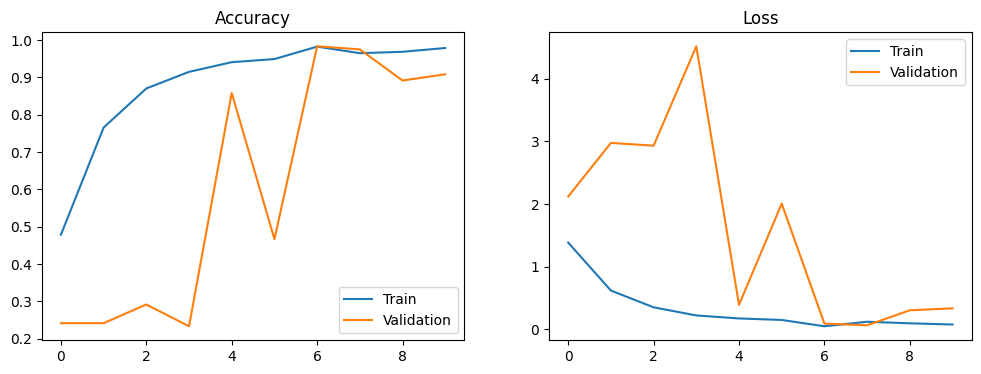

6585

In [ ]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization
import numpy as np
import h5py
import matplotlib.pyplot as plt
import gc

# Clear session
keras.backend.clear_session()

# -------------------------------
# 1. Load Dataset
# -------------------------------
def load_dataset():
    with h5py.File("/content/drive/MyDrive/Signs_Data_Training.h5", "r") as f:
        X_train = np.array(f["train_set_x"])
        Y_train = np.array(f["train_set_y"])

    with h5py.File("/content/drive/MyDrive/Signs_Data_Testing.h5", "r") as f:
        X_test = np.array(f["test_set_x"])
        Y_test = np.array(f["test_set_y"])

    return X_train, Y_train, X_test, Y_test

X_train, Y_train, X_test, Y_test = load_dataset()

print("Train shape:", X_train.shape)

# -------------------------------
# 2. Preprocessing
# -------------------------------

# Normalize
X_train = X_train / 255.0
X_test = X_test / 255.0

# Classes
num_classes = len(np.unique(Y_train))

# One-hot encoding
Y_train = keras.utils.to_categorical(Y_train, num_classes)
Y_test = keras.utils.to_categorical(Y_test, num_classes)

# Resize (ZFNet uses ~224, but 112 saves memory)
IMG_SIZE = 112
X_train = tf.image.resize(X_train, (IMG_SIZE, IMG_SIZE))
X_test = tf.image.resize(X_test, (IMG_SIZE, IMG_SIZE))

# -------------------------------
# 3. Dataset Pipeline
# -------------------------------
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, Y_train))
train_dataset = train_dataset.shuffle(1000).batch(8).prefetch(tf.data.AUTOTUNE)

test_dataset = tf.data.Dataset.from_tensor_slices((X_test, Y_test))
test_dataset = test_dataset.batch(8).prefetch(tf.data.AUTOTUNE)

# -------------------------------
# 4. ZFNet Model
# -------------------------------
model = Sequential()

# Layer 1 (KEY CHANGE: 7x7, stride 2)
model.add(Conv2D(96, (7,7), strides=2, activation='relu', input_shape=X_train.shape[1:]))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(3,3), strides=2))

# Layer 2
model.add(Conv2D(256, (5,5), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(3,3), strides=2))

# Layer 3
model.add(Conv2D(384, (3,3), padding='same', activation='relu'))

# Layer 4
model.add(Conv2D(384, (3,3), padding='same', activation='relu'))

# Layer 5
model.add(Conv2D(256, (3,3), padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=(3,3), strides=2))

# Fully Connected Layers
model.add(Flatten())

model.add(Dense(4096, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(4096, activation='relu'))
model.add(Dropout(0.5))

# Output
model.add(Dense(num_classes, activation='softmax'))

# -------------------------------
# 5. Compile
# -------------------------------
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# -------------------------------
# 6. Train
# -------------------------------
history = model.fit(
    train_dataset,
    epochs=10,
    validation_data=test_dataset
)

# -------------------------------
# 7. Evaluate
# -------------------------------
test_loss, test_acc = model.evaluate(test_dataset)
print("Test Accuracy:", test_acc)

# -------------------------------
# 8. Plot
# -------------------------------
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.legend()
plt.title('Accuracy')

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.legend()
plt.title('Loss')

plt.show()

# -------------------------------
# 9. Clear memory
# -------------------------------
gc.collect()

VGG

Train shape: (1080, 64, 64, 3)
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,139,014 (80.64 MB)

 Trainable params: 6,424,326 (24.51 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

Epoch 1/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 25s 223ms/step - accuracy: 0.5880 - loss: 1.4277 - val_accuracy: 0.9167 - val_loss: 0.4366
Epoch 2/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 8s 115ms/step - accuracy: 0.8037 - loss: 0.5416 - val_accuracy: 0.9417 - val_loss: 0.2761
Epoch 3/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 8s 118ms/step - accuracy: 0.8287 - loss: 0.4598 - val_accuracy: 0.9583 - val_loss: 0.2315
Epoch 4/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 8s 116ms/step - accuracy: 0.8824 - loss: 0.3393 - val_accuracy: 0.9667 - val_loss: 0.1507
Epoch 5/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 8s 114ms/step - accuracy: 0.8926 - loss: 0.2880 - val_accuracy: 0.9667 - val_loss: 0.1440
Epoch 6/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 8s 114ms/step - accuracy: 0.9120 - loss: 0.2596 - val_accuracy: 0.9833 - val_loss: 0.1202
Epoch 7/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 8s 112ms/step - accuracy: 0.9231 - loss: 0.2217 - val_accuracy: 0.9500 - val_loss: 0.1407
Epoch 8/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 8s 113ms/step - accuracy: 0.9120 - loss: 0.2299 - val_accuracy: 0

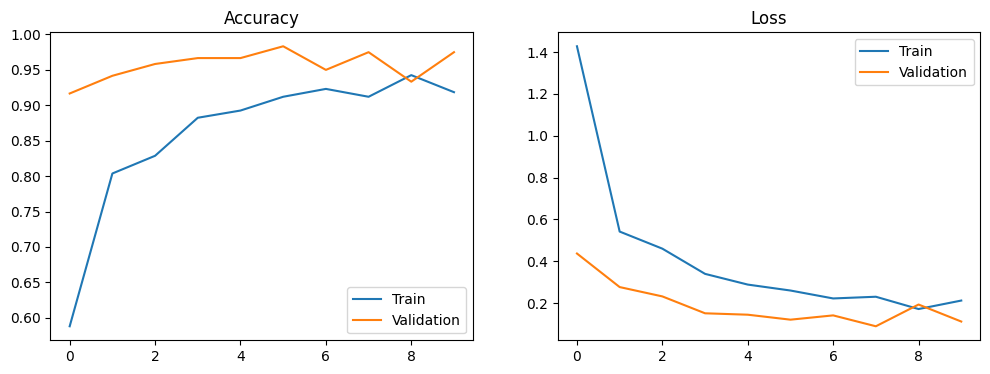

18600

In [ ]:
import tensorflow as tf
from tensorflow import keras
from keras.models import Model
from keras.layers import Dense, Flatten, Dropout
import numpy as np
import h5py
import matplotlib.pyplot as plt
import gc

# Clear session
keras.backend.clear_session()

# -------------------------------
# 1. Load Dataset
# -------------------------------
def load_dataset():
    with h5py.File("/content/drive/MyDrive/Signs_Data_Training.h5", "r") as f:
        X_train = np.array(f["train_set_x"])
        Y_train = np.array(f["train_set_y"])

    with h5py.File("/content/drive/MyDrive/Signs_Data_Testing.h5", "r") as f:
        X_test = np.array(f["test_set_x"])
        Y_test = np.array(f["test_set_y"])

    return X_train, Y_train, X_test, Y_test

X_train, Y_train, X_test, Y_test = load_dataset()

print("Train shape:", X_train.shape)

# -------------------------------
# 2. Preprocessing
# -------------------------------

# Normalize
X_train = X_train / 255.0
X_test = X_test / 255.0

# Classes
num_classes = len(np.unique(Y_train))

# One-hot encoding
Y_train = keras.utils.to_categorical(Y_train, num_classes)
Y_test = keras.utils.to_categorical(Y_test, num_classes)

# Resize to VGG size (224x224)
IMG_SIZE = 224
X_train = tf.image.resize(X_train, (IMG_SIZE, IMG_SIZE))
X_test = tf.image.resize(X_test, (IMG_SIZE, IMG_SIZE))

# -------------------------------
# 3. Load VGG16 Base Model
# -------------------------------
base_model = tf.keras.applications.VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Freeze base layers
for layer in base_model.layers:
    layer.trainable = False

# -------------------------------
# 4. Add Custom Layers
# -------------------------------
x = base_model.output
x = Flatten()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)

output = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

# -------------------------------
# 5. Compile
# -------------------------------
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# -------------------------------
# 6. Train
# -------------------------------
history = model.fit(
    X_train, Y_train,
    epochs=10,
    batch_size=16,
    validation_data=(X_test, Y_test)
)

# -------------------------------
# 7. Evaluate
# -------------------------------
test_loss, test_acc = model.evaluate(X_test, Y_test)
print("Test Accuracy:", test_acc)

# -------------------------------
# 8. Plot
# -------------------------------
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.legend()
plt.title('Accuracy')

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.legend()
plt.title('Loss')

plt.show()

# -------------------------------
# 9. Clear memory
# -------------------------------
gc.collect()

**GoogleNet**

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader
import numpy as np
import h5py
from PIL import Image

# -------------------------------
# 1. Load Dataset
# -------------------------------
def load_dataset():
    with h5py.File("/content/drive/MyDrive/Signs_Data_Training.h5", "r") as f:
        X_train = np.array(f["train_set_x"])
        Y_train = np.array(f["train_set_y"])

    with h5py.File("/content/drive/MyDrive/Signs_Data_Testing.h5", "r") as f:
        X_test = np.array(f["test_set_x"])
        Y_test = np.array(f["test_set_y"])

    return X_train, Y_train, X_test, Y_test

X_train, Y_train, X_test, Y_test = load_dataset()

num_classes = len(np.unique(Y_train))

# -------------------------------
# 2. Custom Dataset Class
# -------------------------------
class SignDataset(Dataset):
    def __init__(self, X, Y, transform=None):
        self.X = X
        self.Y = Y
        self.transform = transform

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        image = self.X[idx]
        label = self.Y[idx]

        image = Image.fromarray(image.astype('uint8'))

        if self.transform:
            image = self.transform(image)

        return image, label

# -------------------------------
# 3. Transforms (IMPORTANT)
# -------------------------------
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# -------------------------------
# 4. DataLoaders
# -------------------------------
train_dataset = SignDataset(X_train, Y_train, transform)
test_dataset = SignDataset(X_test, Y_test, transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16)

# -------------------------------
# 5. Load GoogLeNet Model
# -------------------------------
model = models.googlenet(pretrained=True)

# Replace final layer
model.fc = nn.Linear(model.fc.in_features, num_classes)

# -------------------------------
# 6. Device (GPU/CPU)
# -------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# -------------------------------
# 7. Loss & Optimizer
# -------------------------------
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

# -------------------------------
# 8. Training Loop
# -------------------------------
epochs = 5

for epoch in range(epochs):
    model.train()
    running_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {running_loss:.4f}")

# -------------------------------
# 9. Evaluation
# -------------------------------
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print("Test Accuracy:", correct / total)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=GoogLeNet_Weights.IMAGENET1K_V1`. You can also use `weights=GoogLeNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/googlenet-1378be20.pth" to /root/.cache/torch/hub/checkpoints/googlenet-1378be20.pth


100%|██████████| 49.7M/49.7M [00:00<00:00, 126MB/s]


Epoch 1, Loss: 63.2720
Epoch 2, Loss: 11.2195
Epoch 3, Loss: 4.2659
Epoch 4, Loss: 2.5299
Epoch 5, Loss: 1.3006
Test Accuracy: 0.9916666666666667


**ResNet**

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader
import numpy as np
import h5py
from PIL import Image

# -------------------------------
# 1. Load Dataset
# -------------------------------
def load_dataset():
    with h5py.File("/content/drive/MyDrive/Signs_Data_Training.h5", "r") as f:
        X_train = np.array(f["train_set_x"])
        Y_train = np.array(f["train_set_y"])

    with h5py.File("/content/drive/MyDrive/Signs_Data_Testing.h5", "r") as f:
        X_test = np.array(f["test_set_x"])
        Y_test = np.array(f["test_set_y"])

    return X_train, Y_train, X_test, Y_test

X_train, Y_train, X_test, Y_test = load_dataset()

num_classes = len(np.unique(Y_train))

# -------------------------------
# 2. Custom Dataset
# -------------------------------
class SignDataset(Dataset):
    def __init__(self, X, Y, transform=None):
        self.X = X
        self.Y = Y
        self.transform = transform

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        image = self.X[idx]
        label = self.Y[idx]

        image = Image.fromarray(image.astype('uint8'))

        if self.transform:
            image = self.transform(image)

        return image, label

# -------------------------------
# 3. Transforms
# -------------------------------
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# -------------------------------
# 4. DataLoaders
# -------------------------------
train_dataset = SignDataset(X_train, Y_train, transform)
test_dataset = SignDataset(X_test, Y_test, transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16)

# -------------------------------
# 5. Load ResNet Model
# -------------------------------
model = models.resnet18(pretrained=True)   # you can try resnet34, resnet50

# Replace final layer
model.fc = nn.Linear(model.fc.in_features, num_classes)

# -------------------------------
# 6. Device
# -------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# -------------------------------
# 7. Loss & Optimizer
# -------------------------------
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

# -------------------------------
# 8. Training
# -------------------------------
epochs = 5

for epoch in range(epochs):
    model.train()
    running_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {running_loss:.4f}")

# -------------------------------
# 9. Evaluation
# -------------------------------
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print("Test Accuracy:", correct / total)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 204MB/s]


Epoch 1, Loss: 29.0710
Epoch 2, Loss: 2.2572
Epoch 3, Loss: 0.9668
Epoch 4, Loss: 0.4488
Epoch 5, Loss: 0.4279
Test Accuracy: 0.9833333333333333


🔥 Accuracy Comparison
Model	Params	Accuracy
LeNet	0.33M	81.6%
LeNet + Dropout	1.12M	❌ 33.3%
AlexNet	24.7M	63.3%
ZFNet	46.7M	90.8%
VGG	21.1M	97.5%
GoogLeNet	—	99.16% 🔥
ResNet	—	98.33% 🔥
🧪 Key Observations
1. Best Model ✅

👉 GoogLeNet performs best (99.16%)

Efficient architecture
Inception modules capture multi-scale features
2. Second Best 🔥

👉 ResNet (98.33%)

Residual connections improve learning
Very stable training
3. VGG Performance 💪

👉 VGG (97.5%)

Deep + small filters
High accuracy but heavy
4. ZFNet Insight 👍

👉 ZFNet (90.8%) > AlexNet (63.3%)

Shows improvement due to:
smaller filters
smaller stride
5. AlexNet Issue ⚠️

👉 Low accuracy (63%)

Too coarse (large filters)
Not suitable for your dataset
6. LeNet Behavior

👉 Basic model → decent accuracy (81%)

Works but not powerful enough
7. Dropout Problem ⚠️

👉 LeNet + Dropout → very low accuracy (33%)

Too much dropout → underfitting (high bias)